# Seasonal Agriculture Performance Analysis
### VOIS AICTE Major Project — Data Analytics Track (Batch 1, 2026-2027)

**Author:** Shani Prajapati &nbsp;|&nbsp; Karnavati University

This notebook analyzes a farm-level agricultural dataset spanning three cropping seasons
(**Kharif, Rabi, Zaid**) to identify how agricultural performance — yield, cost, revenue,
profit, resource use, and risk — varies across seasons, and what drives that variation.


## 1. Introduction & Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another. Raw agricultural data does not by
itself explain how performance changes across seasons.

**Problem:** Analyze the agricultural dataset to identify meaningful seasonal patterns,
trends, relationships and variations in agricultural performance, and translate those
findings into evidence-based recommendations.


## 2. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

PALETTE = {"Kharif": "#2E7D32", "Rabi": "#F9A825", "Zaid": "#1565C0"}
SEASON_ORDER = ["Kharif", "Rabi", "Zaid"]

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.shape

(4000, 28)

In [2]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

## 3. Data Cleaning & Preparation

The dataset has 4,000 farm records across 28 columns. Before analysis we check for
missing values, duplicates, and add a couple of derived metrics that make seasonal
comparison easier (profit margin, cost per tonne).


In [4]:
# Missing values
missing = df.isnull().sum()
missing[missing > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [5]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [6]:
# Impute missing numeric values using the median of the same Season + Crop group
# (more accurate than a global median, since both rainfall and yield are season/crop dependent)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [7]:
# Feature engineering
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Tonne'] = df['Total_Cost_INR'] / df['Production_Tonnes']

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,5.000000e-01,4.260000,7.895000,11.650000,1.500000e+01
Rainfall_mm,4000.0,600.720675,288.420788,8.000000e+01,370.425000,581.000000,835.950000,1.395200e+03
Avg_Temperature_C,4000.0,26.818900,3.818180,1.620000e+01,23.900000,26.900000,29.600000,3.970000e+01
Humidity_pct,4000.0,63.210500,11.960834,2.500000e+01,54.775000,63.000000,71.900000,9.500000e+01
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500000e+00,6.600000,7.300000,8.100000,1.100000e+01
Soil_pH,4000.0,6.701010,0.641461,5.200000e+00,6.260000,6.690000,7.140000,8.400000e+00
Soil_Moisture_pct,4000.0,26.505913,6.695965,8.000000e+00,21.700000,26.400000,31.300000,4.700000e+01
Nitrogen_kg_ha,4000.0,120.250825,31.216452,4.000000e+01,98.500000,120.100000,141.225000,2.200000e+02
Phosphorus_kg_ha,4000.0,57.781850,17.015074,1.500000e+01,46.200000,57.500000,69.400000,1.200000e+02
Potassium_kg_ha,4000.0,104.760050,27.742681,3.000000e+01,86.200000,105.100000,123.600000,2.000000e+02


## 4. Exploratory Data Analysis

### 4.1 Dataset composition

In [8]:
print("Season distribution:\n", df['Season'].value_counts(), "\n")
print("Crop distribution:\n", df['Crop'].value_counts(), "\n")
print("States covered:", df['State'].nunique())
print("Irrigation methods:", df['Irrigation_Method'].unique())

Season distribution:
 Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64 

Crop distribution:
 Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64 

States covered: 8
Irrigation methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


The dataset skews toward **Kharif** (1,779 farms) and **Rabi** (1,627), with fewer
**Zaid** farms (594) — consistent with Zaid being a short, water-intensive summer season
that fewer farmers plant in India.

### 4.2 Seasonal summary — environment, resources, and performance

In [9]:
season_summary = df.groupby('Season')[[
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
    'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3',
    'Yield_Tonnes_Ha', 'Profit_INR', 'Profit_Margin_pct',
    'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'
]].mean().reindex(SEASON_ORDER)

season_summary.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Yield_Tonnes_Ha,Profit_INR,Profit_Margin_pct,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,
Kharif,852.10,28.45,71.81,31.20,187.08,5.08,6102.20,5.63,178914.65,-38.64,5.89,54.47
Rabi,435.95,23.49,57.89,24.05,185.41,5.02,5846.99,5.09,87689.47,-44.27,5.19,40.48
Zaid,299.16,31.04,52.01,19.18,184.64,5.17,6419.89,4.64,-24804.82,-69.35,4.41,38.22


**Observation:** Kharif is the wettest and most humid season (monsoon-fed, ~852mm
rainfall) and also the most productive and profitable. Zaid — the hot, dry summer season
with the least rainfall (~299mm) — has both the lowest yield and, on average, a **negative**
profit. Rabi sits in between on almost every metric.


### 4.3 Yield and profit by season

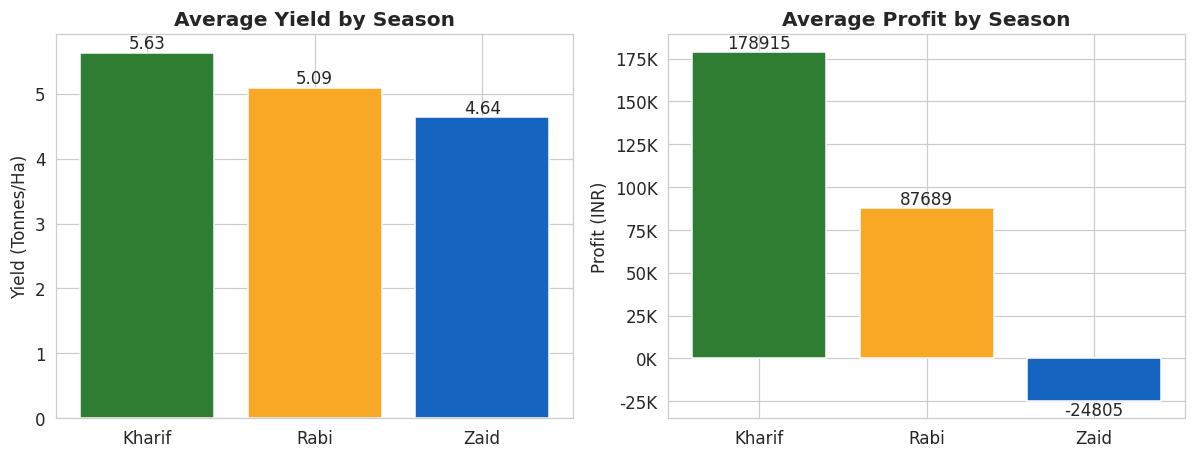

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

bars = axes[0].bar(SEASON_ORDER, season_summary['Yield_Tonnes_Ha'],
                    color=[PALETTE[s] for s in SEASON_ORDER])
axes[0].set_title('Average Yield by Season', fontweight='bold')
axes[0].set_ylabel('Yield (Tonnes/Ha)')
axes[0].bar_label(bars, fmt='%.2f')

bars2 = axes[1].bar(SEASON_ORDER, season_summary['Profit_INR'],
                     color=[PALETTE[s] for s in SEASON_ORDER])
axes[1].set_title('Average Profit by Season', fontweight='bold')
axes[1].set_ylabel('Profit (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].bar_label(bars2, fmt='%.0f')
plt.tight_layout()
plt.show()

### 4.4 Are farms actually profitable? — Profit distribution & loss rate

Average profit hides a lot of spread. We check what fraction of farms are running at an
outright **loss** (Profit_INR < 0) in each season.

In [11]:
loss_pct = df.groupby('Season').apply(lambda g: (g['Profit_INR'] < 0).mean() * 100).reindex(SEASON_ORDER)
loss_pct.round(1)

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
dtype: float64

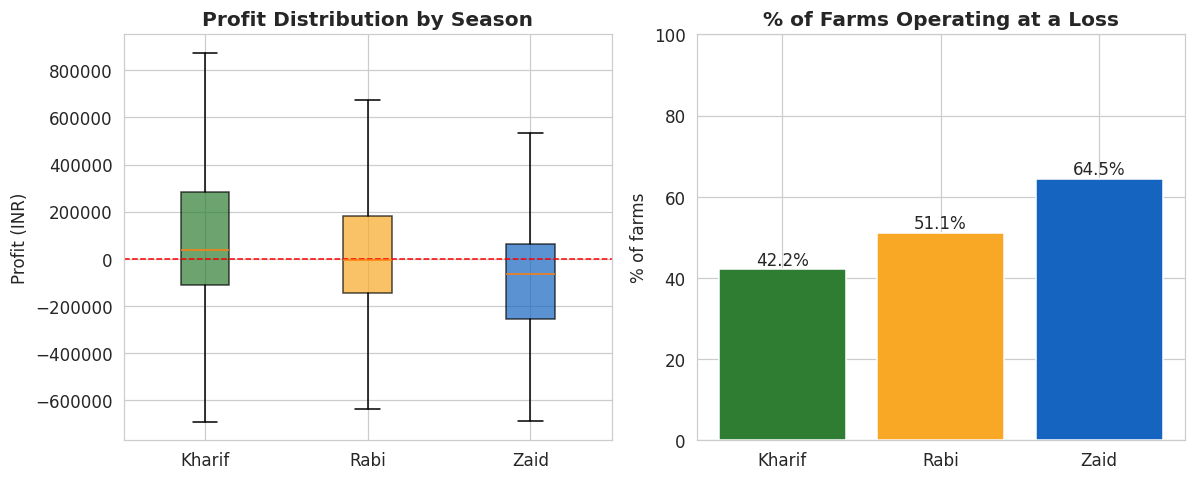

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

data_by_season = [df[df['Season'] == s]['Profit_INR'] for s in SEASON_ORDER]
bp = axes[0].boxplot(data_by_season, tick_labels=SEASON_ORDER, patch_artist=True, showfliers=False)
for patch, s in zip(bp['boxes'], SEASON_ORDER):
    patch.set_facecolor(PALETTE[s]); patch.set_alpha(0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Profit Distribution by Season', fontweight='bold')
axes[0].set_ylabel('Profit (INR)')

bars = axes[1].bar(SEASON_ORDER, loss_pct, color=[PALETTE[s] for s in SEASON_ORDER])
axes[1].set_title('% of Farms Operating at a Loss', fontweight='bold')
axes[1].set_ylabel('% of farms')
axes[1].bar_label(bars, fmt='%.1f%%')
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()

**This is the single most important finding in the dataset.** Nearly half of all
farms (42%) are already operating at a loss even in the best season (Kharif); this climbs
to **51% in Rabi** and **65% in Zaid** — meaning most Zaid-season farms lose money. Average
profit figures mask a genuinely fragile picture: seasonal profitability isn't just
declining, it's failing for a majority of growers in the dry season.


### 4.5 Environmental conditions across seasons

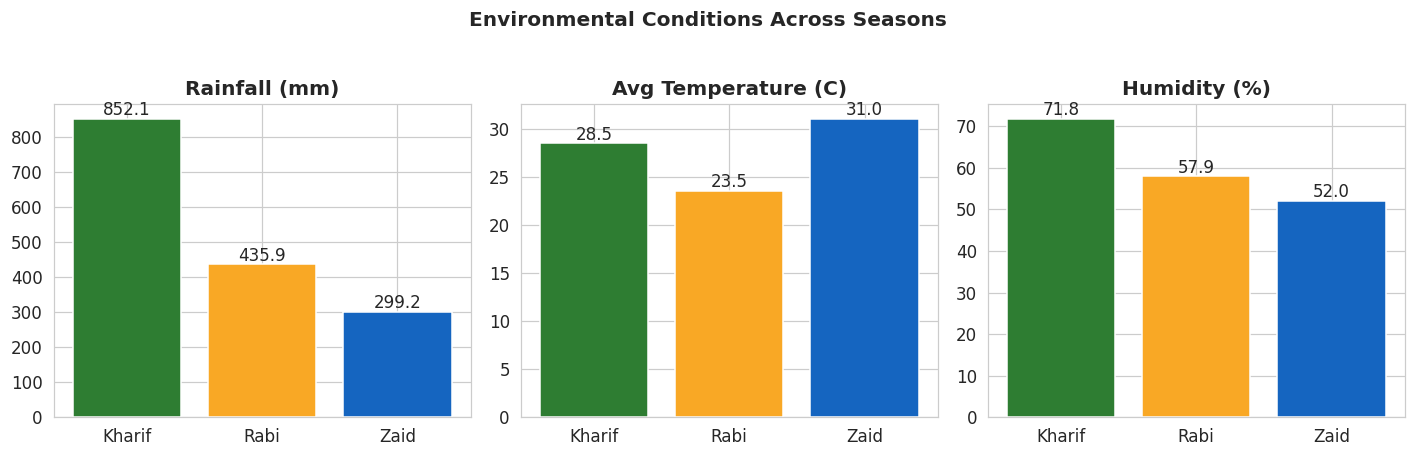

In [13]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']
titles = ['Rainfall (mm)', 'Avg Temperature (C)', 'Humidity (%)']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, env_cols, titles):
    bars = ax.bar(SEASON_ORDER, season_summary[col], color=[PALETTE[s] for s in SEASON_ORDER])
    ax.set_title(title, fontweight='bold')
    ax.bar_label(bars, fmt='%.1f')
plt.suptitle('Environmental Conditions Across Seasons', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 4.6 Resource usage across seasons

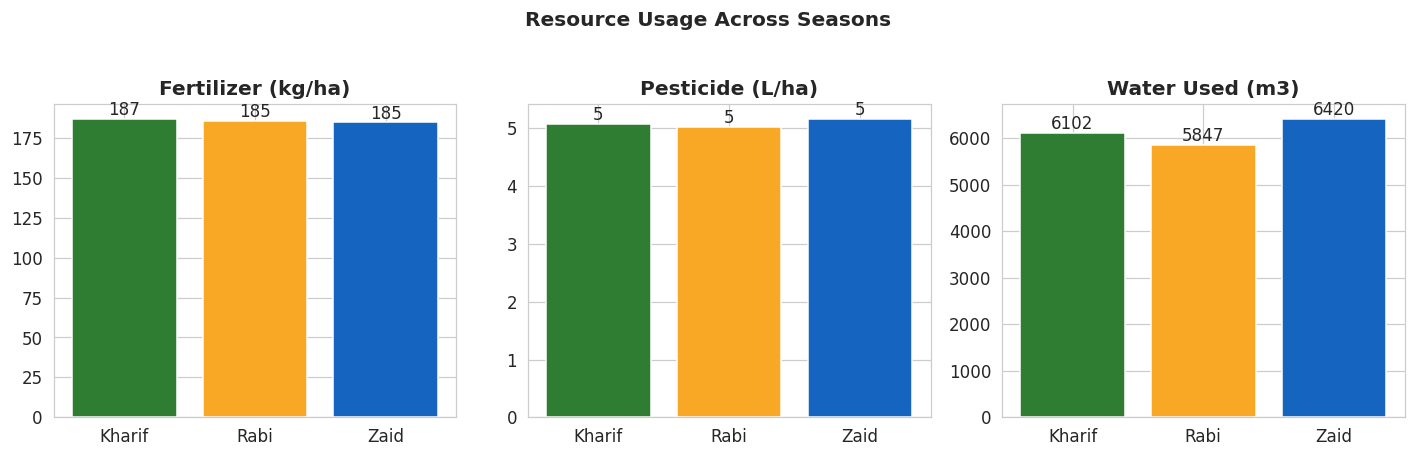

In [14]:
res_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3']
titles = ['Fertilizer (kg/ha)', 'Pesticide (L/ha)', 'Water Used (m3)']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, res_cols, titles):
    bars = ax.bar(SEASON_ORDER, season_summary[col], color=[PALETTE[s] for s in SEASON_ORDER])
    ax.set_title(title, fontweight='bold')
    ax.bar_label(bars, fmt='%.0f')
plt.suptitle('Resource Usage Across Seasons', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Observation:** Fertilizer and pesticide usage are almost **flat across seasons**
(~185 kg/ha fertilizer everywhere) despite yield and profit dropping sharply from Kharif to
Zaid. Zaid also uses slightly *more* water than Kharif despite far lower rainfall — i.e.
irrigation is compensating for missing rain, but not compensating enough to protect yield
or profit. Inputs aren't scaling down with season, but outcomes are.


### 4.7 Crop mix by season

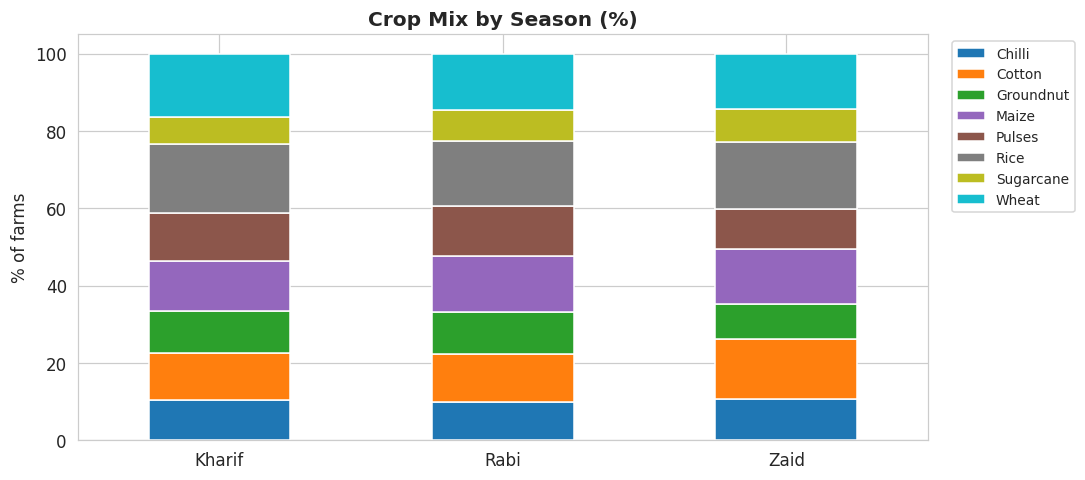

In [15]:
crop_season = pd.crosstab(df['Season'], df['Crop'], normalize='index').reindex(SEASON_ORDER) * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
crop_season.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Crop Mix by Season (%)', fontweight='bold')
ax.set_ylabel('% of farms'); ax.set_xlabel('')
plt.xticks(rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### 4.8 Relationships between variables — correlation analysis

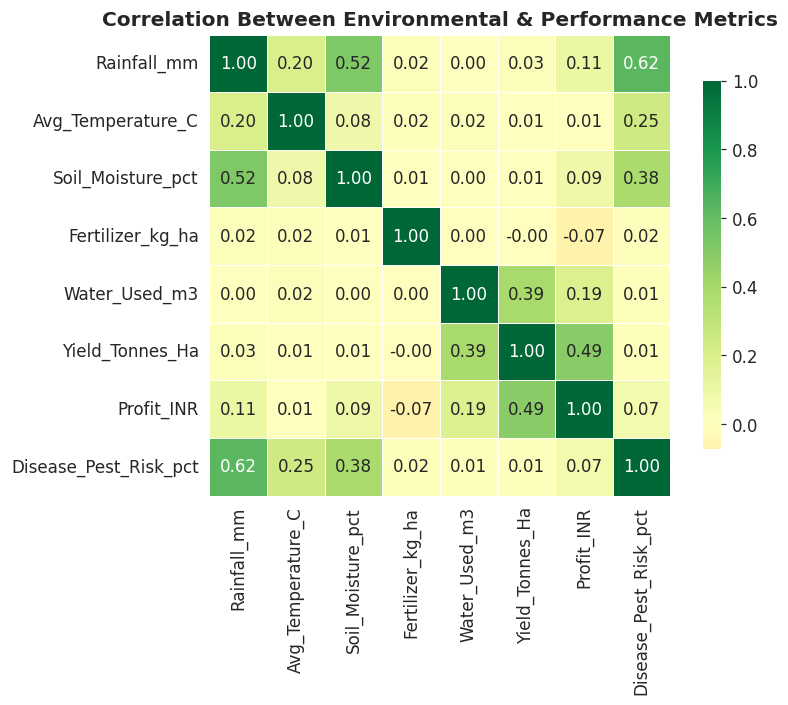

In [16]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct', 'Fertilizer_kg_ha',
             'Water_Used_m3', 'Yield_Tonnes_Ha', 'Profit_INR', 'Disease_Pest_Risk_pct']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Between Environmental & Performance Metrics', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Yield correlates strongly with **Water_Used_m3 (r=0.39)** and,
in turn, **Profit_INR (r=0.49)** — water availability is the biggest lever on outcomes,
far more than rainfall alone (r=0.03) or fertilizer (r≈0.00). This confirms the resource-usage
finding above: fertilizer application is not a meaningful yield driver in this dataset, while
irrigation/water access is.


### 4.9 Is the seasonal pattern consistent across states?

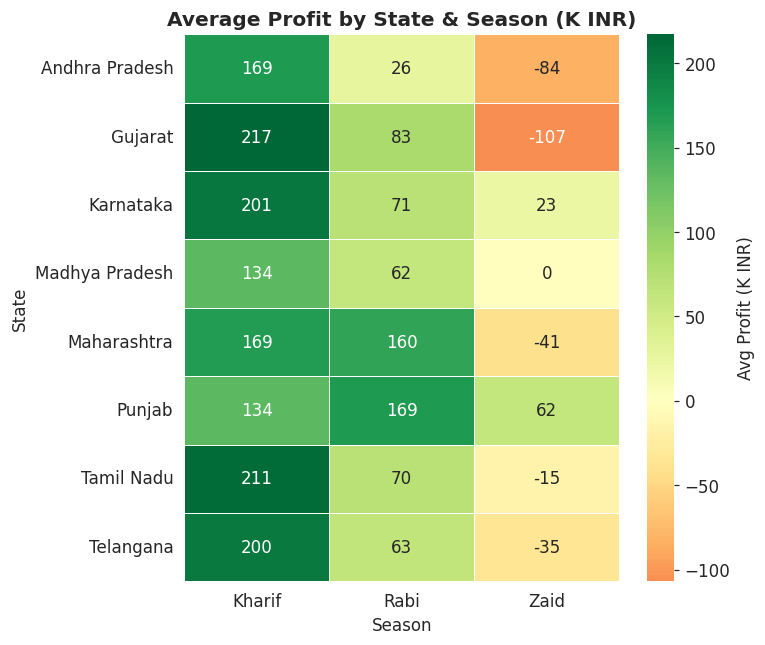

In [17]:
state_season_profit = df.pivot_table(values='Profit_INR', index='State', columns='Season',
                                       aggfunc='mean').reindex(columns=SEASON_ORDER)

plt.figure(figsize=(7, 6))
sns.heatmap(state_season_profit / 1000, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Avg Profit (K INR)'})
plt.title('Average Profit by State & Season (K INR)', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The Kharif > Rabi > Zaid profit ranking holds in **7 of 8 states**
(Punjab is the exception, where Rabi wheat outperforms Kharif). Zaid is loss-making in 6 of
8 states — this is a structural, dataset-wide seasonal pattern, not an artifact of one
region.


### 4.10 Water efficiency vs yield

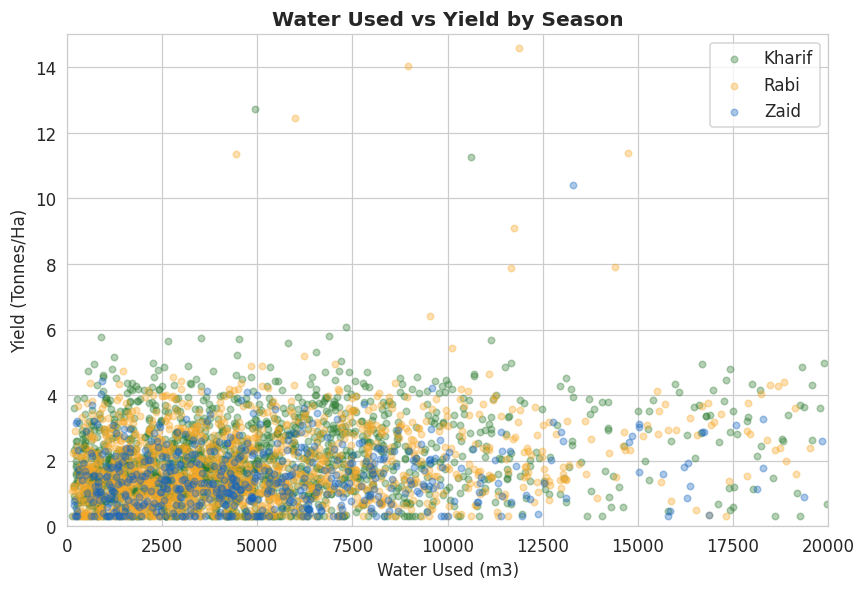

In [18]:
plt.figure(figsize=(8, 5.5))
for s in SEASON_ORDER:
    sub = df[df['Season'] == s]
    plt.scatter(sub['Water_Used_m3'], sub['Yield_Tonnes_Ha'], alpha=0.35, s=18,
                color=PALETTE[s], label=s)
plt.xlim(0, 20000); plt.ylim(0, 15)
plt.xlabel('Water Used (m3)'); plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Water Used vs Yield by Season', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Key Findings

1. **Kharif is the strongest season** on almost every metric — highest rainfall (852mm),
   highest yield (5.63 t/ha) and highest average profit (₹1.79L) — but even here, 42% of
   farms still lose money.
2. **Zaid is structurally loss-making** — average profit is **negative** (-₹24.8K) and
   65% of Zaid farms operate at a loss, driven by the lowest rainfall (299mm) and highest
   reliance on irrigation relative to output.
3. **Profitability is fragile dataset-wide** — even the best season has a large share of
   loss-making farms, so seasonal averages understate the risk individual farmers face.
4. **Inputs don't scale with season, outcomes do** — fertilizer/pesticide use is nearly flat
   across seasons while yield and profit fall sharply from Kharif to Zaid, suggesting input
   efficiency drops in the dry season.
5. **Water access, not rainfall or fertilizer, is the strongest driver of yield and profit**
   (r=0.39 and r=0.49 respectively) — irrigation infrastructure matters more than natural
   rainfall once a farm is already growing a crop.
6. **The seasonal pattern is consistent across geography** — 7 of 8 states follow the same
   Kharif > Rabi > Zaid ranking, indicating a genuine seasonal effect rather than a regional
   one.
7. **Disease/pest risk tracks humidity** — Kharif (highest humidity, 71.8%) also has the
   highest disease/pest risk (54.5%), while Zaid (52% humidity) has the lowest (38.2%).


## 6. Recommendations

- **Prioritize irrigation investment for Zaid-season farms** — since water access (not
  rainfall) drives yield, targeted drip/micro-irrigation subsidies for summer-season farms
  could convert loss-making Zaid farms toward breakeven.
- **Reassess fertilizer application by season** — since fertilizer shows near-zero
  correlation with yield, a review of season-specific dosage (especially in Zaid, where
  ROI is worst) could cut costs without hurting output.
- **Target disease/pest management resources at Kharif** — the monsoon season's high
  humidity drives the highest disease/pest risk; preventive interventions here protect the
  season that already contributes most to farmer income.
- **Use state-level Zaid outliers (Punjab, Karnataka) as case studies** — understanding
  what makes Zaid profitable there (irrigation infrastructure, crop choice) could inform
  interventions for the other six states.
- **Treat "average profit" with caution in planning** — given how many farms fall below
  breakeven even in good seasons, planning and subsidy design should look at the loss-rate
  distribution, not just the season-wise mean.


## 7. Conclusion

This analysis confirms that agricultural performance in this dataset varies significantly
and consistently across seasons — with Kharif outperforming Rabi, and Rabi outperforming
Zaid, across yield, profit, and risk metrics, and across almost all states. The variation is
driven less by the environmental factors farmers can't control (rainfall, temperature) and
more by resource access — chiefly water — that policy and infrastructure decisions **can**
influence. The high loss rate even in the best season is the most actionable finding: it
points to opportunities for evidence-based, season-specific agricultural planning rather
than one-size-fits-all support.
